<a href="https://colab.research.google.com/github/np03cs4a240010-collab/Ai/blob/main/2462976dilliramankhadka.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

classification task

In [2]:
import pandas as pd

path = "/content/drive/MyDrive/Ai/Steel_industry_data.csv"
df = pd.read_csv(path)
df.head(2)

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load


Basic info + shape

In [3]:
df.shape, df.columns

((35040, 11),
 Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
        'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
        'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
        'WeekStatus', 'Day_of_week', 'Load_Type'],
       dtype='object'))

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

Missing values, duplicates

In [5]:
df.isna().sum()

,0
date,0
Usage_kWh,0
Lagging_Current_Reactive.Power_kVarh,0
Leading_Current_Reactive_Power_kVarh,0
CO2(tCO2),0
Lagging_Current_Power_Factor,0
Leading_Current_Power_Factor,0
NSM,0
WeekStatus,0
Day_of_week,0


In [6]:
df.duplicated().sum()

np.int64(0)

Target distribution (imbalance check)

In [7]:
df['Load_Type'].value_counts()

,count
Load_Type,
Light_Load,18072
Medium_Load,9696
Maximum_Load,7272


In [8]:
df['Load_Type'].value_counts(normalize=True)*100

,proportion
Load_Type,
Light_Load,51.575342
Medium_Load,27.671233
Maximum_Load,20.753425


Convert date column

In [9]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df[['date']].head()

,date
0,2018-01-01 00:15:00
1,2018-01-01 00:30:00
2,2018-01-01 00:45:00
3,2018-01-01 01:00:00
4,2018-01-01 01:15:00


In [10]:
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['dayofweek'] = df['date'].dt.dayofweek

Exploratory Data Analysis (Part 2: Visuals + Insights)

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

Target count bar chart

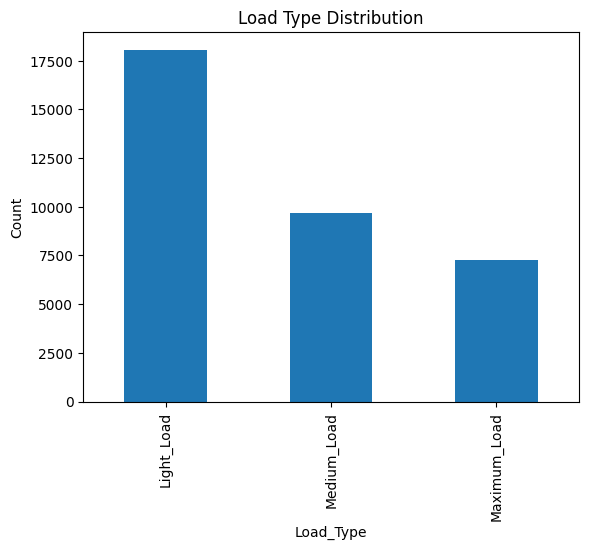

In [12]:
df['Load_Type'].value_counts().plot(kind='bar')
plt.title("Load Type Distribution")
plt.xlabel("Load_Type")
plt.ylabel("Count")
plt.show()

boxplot

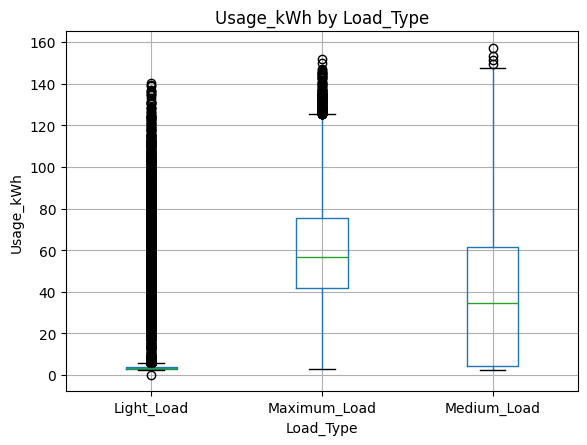

In [13]:
df.boxplot(column='Usage_kWh', by='Load_Type')
plt.title("Usage_kWh by Load_Type")
plt.suptitle("")
plt.xlabel("Load_Type")
plt.ylabel("Usage_kWh")
plt.show()

CO2 by Load_Type

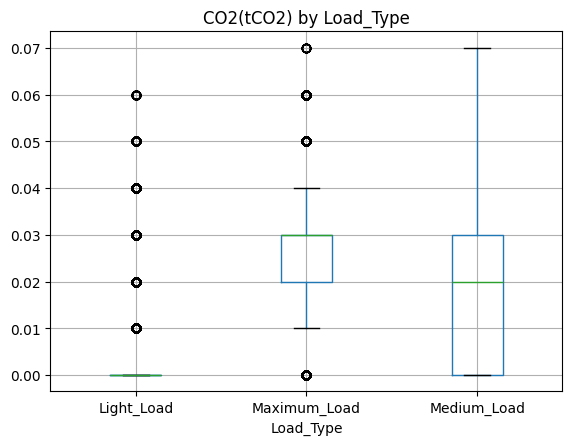

In [14]:
df.boxplot(column='CO2(tCO2)', by='Load_Type')
plt.title("CO2(tCO2) by Load_Type")
plt.suptitle("")
plt.show()

Correlation heatmap

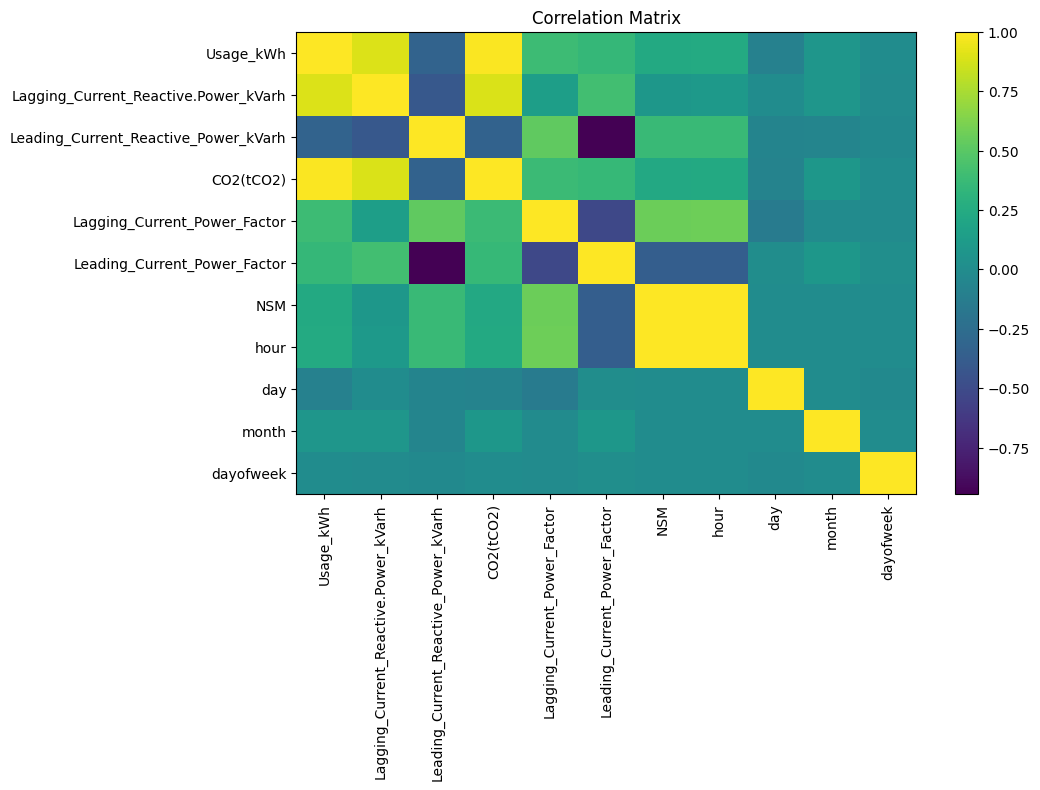

In [15]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(10,6))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

Prepare Data for ML (Encoding + Train/Test Split)

In [16]:
target = 'Load_Type'
X = df.drop(columns=[target])
y = df[target]

handle categorical + scaling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Identify column types
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['int64','float64']).columns

# Preprocess
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((28032, 14), (7008, 14))

Build Neural Network

In [20]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np # Import numpy for NaN checks

# Identify numerical columns (from previous cell hziHfh6rNIZM where preprocess was defined)
# We assume num_cols and cat_cols are still in scope from previous execution.
# If not, they would need to be re-derived based on the current X.
# For the purpose of this fix, we will use the existing definitions.
num_cols = X.select_dtypes(include=['int64','float64']).columns

# Drop rows with NaN values from X_train and y_train
nan_mask_train = X_train[num_cols].isna().any(axis=1)
X_train_cleaned = X_train[~nan_mask_train].drop(columns=['date'])
y_train_cleaned = y_train[~nan_mask_train]

# Drop rows with NaN values from X_test and y_test
nan_mask_test = X_test[num_cols].isna().any(axis=1)
X_test_cleaned = X_test[~nan_mask_test].drop(columns=['date'])
y_test_cleaned = y_test[~nan_mask_test]

mlp_model = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', MLPClassifier(hidden_layer_sizes=(64,32),
                          activation='relu',
                          solver='adam',
                          max_iter=300,
                          random_state=42))
])

mlp_model.fit(X_train_cleaned, y_train_cleaned)

pred_train = mlp_model.predict(X_train_cleaned)
pred_test = mlp_model.predict(X_test_cleaned)

print("MLP Train Accuracy:", accuracy_score(y_train_cleaned, pred_train))
print("MLP Test Accuracy:", accuracy_score(y_test_cleaned, pred_test))
print("\nTest Classification Report:\n", classification_report(y_test_cleaned, pred_test))

MLP Train Accuracy: 0.9903933297081747
MLP Test Accuracy: 0.967741935483871

Test Classification Report:
               precision    recall  f1-score   support

  Light_Load       0.98      0.99      0.99      1465
Maximum_Load       0.94      0.96      0.95       563
 Medium_Load       0.96      0.94      0.95       762

    accuracy                           0.97      2790
   macro avg       0.96      0.96      0.96      2790
weighted avg       0.97      0.97      0.97      2790



Two Classical Models

Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=2000))
])

lr_model.fit(X_train_cleaned, y_train_cleaned)
lr_pred = lr_model.predict(X_test_cleaned)

print("LR Test Accuracy:", accuracy_score(y_test_cleaned, lr_pred))
print(classification_report(y_test_cleaned, lr_pred))

LR Test Accuracy: 0.7512544802867384
              precision    recall  f1-score   support

  Light_Load       0.91      0.92      0.91      1465
Maximum_Load       0.54      0.59      0.56       563
 Medium_Load       0.61      0.55      0.58       762

    accuracy                           0.75      2790
   macro avg       0.68      0.69      0.68      2790
weighted avg       0.75      0.75      0.75      2790



Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier

preprocess_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

rf_model = Pipeline(steps=[
    ('prep', preprocess_rf),
    ('clf', RandomForestClassifier(n_estimators=300, random_state=42))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("RF Test Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

RF Test Accuracy: 0.9489155251141552
              precision    recall  f1-score   support

  Light_Load       0.99      0.99      0.99      3615
Maximum_Load       0.90      0.90      0.90      1454
 Medium_Load       0.91      0.91      0.91      1939

    accuracy                           0.95      7008
   macro avg       0.93      0.93      0.93      7008
weighted avg       0.95      0.95      0.95      7008



GridSearch for LR

In [26]:
from sklearn.model_selection import GridSearchCV

lr_params = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(lr_model, lr_params, cv=5, scoring='f1_weighted')
grid_lr.fit(X_train_cleaned, y_train_cleaned)

grid_lr.best_params_, grid_lr.best_score_

({'clf__C': 0.1, 'clf__solver': 'lbfgs'}, np.float64(0.7681076596682634))

GridSearch for RF

In [28]:
rf_params = {
    'clf__n_estimators': [200, 300],
    'clf__max_depth': [None, 15, 30],
    'clf__min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf_model, rf_params, cv=5, scoring='f1_weighted')
grid_rf.fit(X_train_cleaned, y_train_cleaned)

grid_rf.best_params_, grid_rf.best_score_

({'clf__max_depth': None,
  'clf__min_samples_split': 5,
  'clf__n_estimators': 200},
 np.float64(0.9902933956584258))

Feature Selection

In [30]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

kbest_lr = Pipeline(steps=[
    ('prep', preprocess),
    ('select', SelectKBest(score_func=f_classif, k=10)),
    ('clf', LogisticRegression(max_iter=2000))
])

kbest_lr.fit(X_train_cleaned, y_train_cleaned)
pred = kbest_lr.predict(X_test_cleaned)
print("LR + KBest Accuracy:", accuracy_score(y_test_cleaned, pred))
print(classification_report(y_test_cleaned, pred))

LR + KBest Accuracy: 0.7537634408602151
              precision    recall  f1-score   support

  Light_Load       0.90      0.91      0.91      1465
Maximum_Load       0.55      0.60      0.57       563
 Medium_Load       0.61      0.57      0.59       762

    accuracy                           0.75      2790
   macro avg       0.69      0.69      0.69      2790
weighted avg       0.75      0.75      0.75      2790



For Random Forest:

In [32]:
kbest_rf = Pipeline(steps=[
    ('prep', preprocess_rf),
    ('select', SelectKBest(score_func=f_classif, k=8)),
    ('clf', RandomForestClassifier(random_state=42))
])

kbest_rf.fit(X_train_cleaned, y_train_cleaned)
pred = kbest_rf.predict(X_test_cleaned)
print("RF + KBest Accuracy:", accuracy_score(y_test_cleaned, pred))
print(classification_report(y_test_cleaned, pred))

RF + KBest Accuracy: 0.8935483870967742
              precision    recall  f1-score   support

  Light_Load       0.98      0.98      0.98      1465
Maximum_Load       0.78      0.80      0.79       563
 Medium_Load       0.82      0.80      0.81       762

    accuracy                           0.89      2790
   macro avg       0.86      0.86      0.86      2790
weighted avg       0.89      0.89      0.89      2790



Comparison Table

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score

def metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted'),
        "Recall": recall_score(y_true, y_pred, average='weighted'),
        "F1": f1_score(y_true, y_pred, average='weighted')
    }

final_lr = grid_lr.best_estimator_
final_rf = grid_rf.best_estimator_

lr_test_pred = final_lr.predict(X_test_cleaned)
rf_test_pred = final_rf.predict(X_test_cleaned)

lr_m = metrics(y_test_cleaned, lr_test_pred)
rf_m = metrics(y_test_cleaned, rf_test_pred)

results = pd.DataFrame([
    ["Logistic Regression", "Selected (KBest)", grid_lr.best_score_, lr_m["Accuracy"], lr_m["Precision"], lr_m["Recall"], lr_m["F1"]],
    ["Random Forest", "Selected (KBest)", grid_rf.best_score_, rf_m["Accuracy"], rf_m["Precision"], rf_m["Recall"], rf_m["F1"]]
], columns=["Model", "Features", "CV Score", "Accuracy", "Precision", "Recall", "F1-Score"])

results

,Model,Features,CV Score,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,Selected (KBest),0.768108,0.750896,0.750889,0.750896,0.750237
1,Random Forest,Selected (KBest),0.990293,0.991039,0.991090,0.991039,0.991033
